# 感知机的极限（1969）— 为什么 XOR 解不了？

配套文档：[docs/02-minsky-papert-1969.md](../docs/02-minsky-papert-1969.md)

**目标**：用数学和代码证明，单层感知机**永远无法**解 XOR——不是训练不够，而是数学上不可能。

**你需要懂**：节点 01 的感知机 + 基础代数（不需要微积分）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
print('依赖库加载完成:', 'numpy', np.__version__)

依赖库加载完成: numpy 1.26.4


## 第一步：XOR 是什么，长什么样？

XOR（异或）规则：两个输入**不同**时输出 1，**相同**时输出 0。

先用代码建好数据，再画出来看看。

/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_39113/4235963042.py:18: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_39113/4235963042.py:18: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_39113/4235963042.py:18: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_39113/4235963042.py:18: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_39113/4235963042.py:18: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

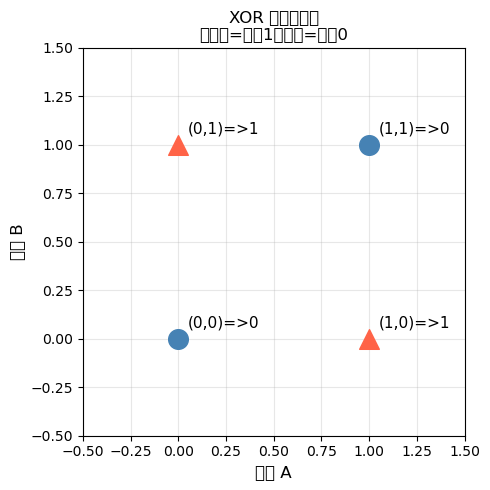

你能画一条直线把红三角和蓝圆完全分开吗？试试看...


In [2]:
# XOR 真值表
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

fig, ax = plt.subplots(figsize=(5, 5))
for xi, yi in zip(X_xor, y_xor):
    color = 'tomato' if yi == 1 else 'steelblue'
    marker = '^' if yi == 1 else 'o'
    ax.scatter(xi[0], xi[1], c=color, marker=marker, s=200, zorder=5)
    label = '({},{})=>{}'.format(int(xi[0]), int(xi[1]), yi)
    ax.annotate(label, xy=(xi[0], xi[1]), xytext=(xi[0]+0.05, xi[1]+0.06), fontsize=11)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('输入 A', fontsize=12)
ax.set_ylabel('输入 B', fontsize=12)
ax.set_title('XOR 的四个样本\n红三角=输出1，蓝圆=输出0', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02-xor-scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('你能画一条直线把红三角和蓝圆完全分开吗？试试看...')

## 第二步：试着用感知机硬训——看看会发生什么

In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.perceptron import Perceptron

p = Perceptron(learning_rate=0.1, max_epochs=200)
p.fit(X_xor, y_xor)

preds = p.predict(X_xor)
print('XOR 预测结果：', preds)
print('正确标签：    ', y_xor)
print('准确率：{}%'.format(int(p.accuracy(X_xor, y_xor) * 100)))
print()
print('最后 10 轮的错误数：', p.history[-10:])
print('注意：错误数从来没有降到 0 ——感知机陷入了无限循环')

达到最大轮数 200，停止训练（可能未收敛）
XOR 预测结果： [1 1 0 0]
正确标签：     [0 1 1 0]
准确率：50%

最后 10 轮的错误数： [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
注意：错误数从来没有降到 0 ——感知机陷入了无限循环


## 第三步：穷举验证——任何权重都不行

感知机用的公式是：

```
预测 = 1  如果  w1*x1 + w2*x2 + b >= 0
预测 = 0  否则
```

下面我们在一个密集网格上，穷举尝试约 12.5 万种权重组合（50x50x50）。

In [4]:
vals = np.linspace(-3, 3, 50)
W1, W2, B = np.meshgrid(vals, vals, vals)
W1 = W1.ravel()
W2 = W2.ravel()
B  = B.ravel()

p00 = ((W1*0 + W2*0 + B) >= 0).astype(int)
p01 = ((W1*0 + W2*1 + B) >= 0).astype(int)
p10 = ((W1*1 + W2*0 + B) >= 0).astype(int)
p11 = ((W1*1 + W2*1 + B) >= 0).astype(int)

correct = (p00 == 0) & (p01 == 1) & (p10 == 1) & (p11 == 0)
print('测试了 {:,} 种权重组合'.format(len(W1)))
print('其中正确分类 XOR 的组合数：{}'.format(correct.sum()))
if correct.sum() == 0:
    print('\n结论：没有任何权重能让感知机正确分类 XOR。')
    print('这不是运气不好——数学已经证明了这是不可能的。')

测试了 125,000 种权重组合
其中正确分类 XOR 的组合数：0

结论：没有任何权重能让感知机正确分类 XOR。
这不是运气不好——数学已经证明了这是不可能的。


## 第四步：代数证明（只用初中数学）

要让感知机正确分类 XOR，需要同时满足：

1. (0,0)→0：`b < 0`
2. (0,1)→1：`w2 + b >= 0`
3. (1,0)→1：`w1 + b >= 0`
4. (1,1)→0：`w1 + w2 + b < 0`

从条件 1 推出 `-b > 0`，代入 2 和 3 得 `w2 > 0` 且 `w1 > 0`，
所以 `w1 + w2 + b > 0`，和条件 4 矛盾！

下面用随机抽样验证这个代数矛盾：

In [5]:
rng = np.random.default_rng(42)
N = 500_000
w1 = rng.uniform(-10, 10, N)
w2 = rng.uniform(-10, 10, N)
b  = rng.uniform(-10, 10, N)

mask = (b < 0) & (w2 + b >= 0) & (w1 + b >= 0)
print('满足条件 1+2+3 的组合数：{:,}'.format(mask.sum()))

cond4 = (w1 + w2 + b < 0)
both = mask & cond4
print('同时满足条件 4 的组合数：{}'.format(both.sum()))
if both.sum() == 0:
    print('\n代数验证完成：满足条件 1+2+3 的权重，100% 违反条件 4。')

满足条件 1+2+3 的组合数：20,811
同时满足条件 4 的组合数：0

代数验证完成：满足条件 1+2+3 的权重，100% 违反条件 4。


## 第五步：那多层网络能解吗？

XOR 可以被分解成两步：

- 第一层：分别学 OR（有一个 1 就是 1）和 NAND（不能两个都是 1）
- 第二层：对第一层输出做 AND

每一层本身都是线性可分的！

In [6]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0])
y_or   = np.array([0, 1, 1, 1])
y_nand = np.array([1, 1, 1, 0])

p_or   = Perceptron(learning_rate=0.1, max_epochs=100).fit(X, y_or)
p_nand = Perceptron(learning_rate=0.1, max_epochs=100).fit(X, y_nand)
print('OR   准确率：', p_or.accuracy(X, y_or))
print('NAND 准确率：', p_nand.accuracy(X, y_nand))

X_layer2 = np.column_stack([p_or.predict(X), p_nand.predict(X)])
print('\n第一层输出（作为第二层输入）：')
for xi_orig, xi_l2, yi in zip(X, X_layer2, y_xor):
    print('  原始输入 {} -> 层 2 输入 {} -> 目标 XOR={}'.format(xi_orig.astype(int), xi_l2, yi))

y_layer2 = y_xor
p_and = Perceptron(learning_rate=0.1, max_epochs=100).fit(X_layer2, y_layer2)

final_preds = p_and.predict(X_layer2)
print('\n两层网络的 XOR 预测结果：', final_preds)
print('正确答案：              ', y_xor)
if np.array_equal(final_preds, y_xor):
    print('\n两层网络完美解决了 XOR！这是单层感知机做不到的。')

收敛！第 4 轮，错误数降到 0
收敛！第 6 轮，错误数降到 0
OR   准确率： 1.0
NAND 准确率： 1.0

第一层输出（作为第二层输入）：
  原始输入 [0 0] -> 层 2 输入 [0 1] -> 目标 XOR=0
  原始输入 [0 1] -> 层 2 输入 [1 1] -> 目标 XOR=1
  原始输入 [1 0] -> 层 2 输入 [1 1] -> 目标 XOR=1
  原始输入 [1 1] -> 层 2 输入 [1 0] -> 目标 XOR=0
收敛！第 6 轮，错误数降到 0

两层网络的 XOR 预测结果： [0 1 1 0]
正确答案：               [0 1 1 0]

两层网络完美解决了 XOR！这是单层感知机做不到的。


## 总结

| 能力 | 单层感知机 | 两层网络 |
|------|-----------|----------|
| AND  | OK | OK |
| OR   | OK | OK |
| XOR  | NO | OK |

**Minsky & Papert（1969）的贡献**：用数学严格证明了单层感知机的边界，同时指出了解决方向是多层网络。

**历史的吊证**：这个“泼冷水”的发现反而最终打开了深度学习的大门——因为它清楚定义了问题，为 1986 年的反向传播算法铺了路。

> 下一节：节点 03 — 反向传播（1986） *(待建)*

In [7]:
# 自检
assert p_or.accuracy(X, y_or) == 1.0, 'OR 必须 100% 准确'
assert p_nand.accuracy(X, y_nand) == 1.0, 'NAND 必须 100% 准确'
assert np.array_equal(final_preds, y_xor), '两层网络必须完美解决 XOR'
assert correct.sum() == 0, '穷举搜索应找不到任何单层解'
print('自检通过 — 节点 02 所有验证完成')

自检通过 — 节点 02 所有验证完成
